In [23]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [24]:
df=pd.read_csv("/Users/priyanshukumar/Desktop/Advance_Coding/Project_1/CIRC_model_ready.csv")
print(df.shape)
df.isnull().sum()
df.head()

(1141, 14)


,D,t,Fy,fc,L,Dt,LD,Ac,As,SteelCap,ConcCap,Squash,Xi,Pexp
0,94.996,12.4968,274.618291,27.365302,1420.114,7.601626,14.949198,3848.714899,3238.906636,889.463004,105.321247,994.784252,8.445238,947.026382
1,94.996,12.7508,272.618810,27.365302,1420.114,7.450199,14.949198,3793.058149,3294.563385,898.159951,103.798183,1001.958134,8.652945,937.685116
2,94.996,12.3952,272.618810,27.365302,1420.114,7.663934,14.949198,3871.091101,3216.530433,876.886700,105.933579,982.820279,8.277703,906.992387
3,94.996,12.5984,274.618291,27.365302,860.044,7.540323,9.053476,3826.403555,3261.217979,895.590107,104.710691,1000.300798,8.552996,1017.753106
4,94.996,12.7000,272.618810,27.365302,860.044,7.480000,9.053476,3804.157070,3283.464465,895.134176,104.101909,999.236085,8.598634,1007.967018


#### Transforming Data

In [25]:
x=df.drop("Pexp",axis=1)
y=df["Pexp"]

#### Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

#### Data PreProcessing

In [27]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### Building the Base ML models

In [28]:
# for all the models
from sklearn.model_selection import GridSearchCV

### KNN Models

In [29]:
# KNN Model
from sklearn.neighbors import KNeighborsRegressor

param_grid = {
    "n_neighbors": list(range(2, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"]
}

grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train_scaled, y_train)

best_knn = grid.best_estimator_

print("Best Parameters :", grid.best_params_)
print("Best CV R²      :", round(grid.best_score_, 4))

yk_train_pred = best_knn.predict(x_train_scaled)
yk_pred = best_knn.predict(x_test_scaled)


# evaluation matrix
print(f"r2_score: {r2_score(y_test,yk_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test,yk_pred)}")
print(f"MAE: {mean_absolute_error(y_test,yk_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test,yk_pred)}")

Fitting 5 folds for each of 114 candidates, totalling 570 fits
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best CV R²      : 0.9579
r2_score: 0.9471032904064757
RMSE: 926.8729871628042
MAE: 289.74979725447105
MAPE: 0.15627601252078652


7 Varients of KNN

                       Model  R2 Score      RMSE      MAE  MAPE (%)
6       Cosine + Brute Force    0.9598   808.170  288.808     17.44
3        Chebyshev + KD-Tree    0.9545   859.537  331.589     21.02
4      Chebyshev + Ball-Tree    0.9543   861.475  332.025     21.11
2    Chebyshev + Brute Force    0.9539   865.116  336.108     21.53
0        Minkowski + KD-Tree    0.9496   904.487  302.010     17.99
1      Minkowski + Ball-Tree    0.9496   904.487  302.027     17.99
5  Mahalanobis + Brute Force    0.7726  1921.940  460.665     17.68


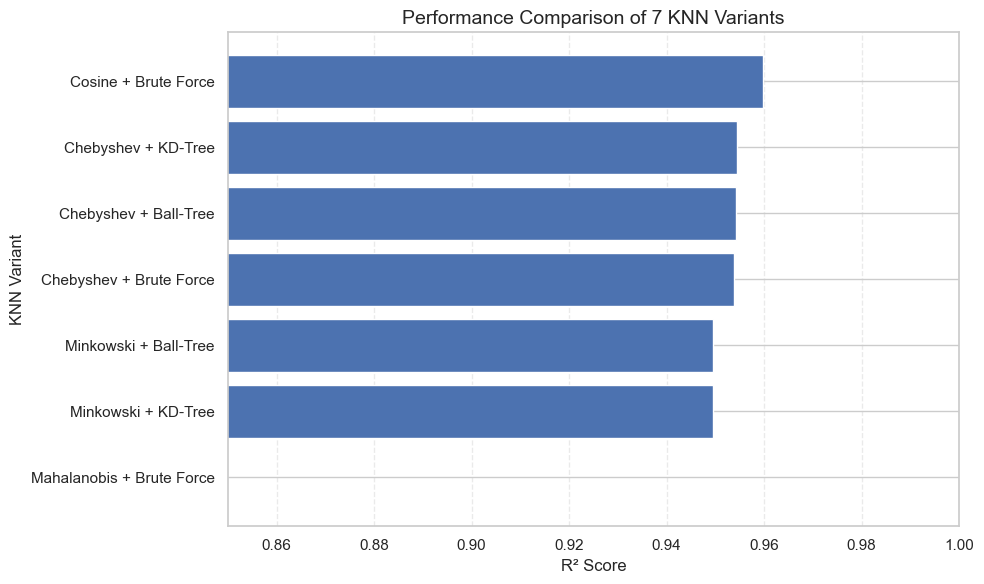

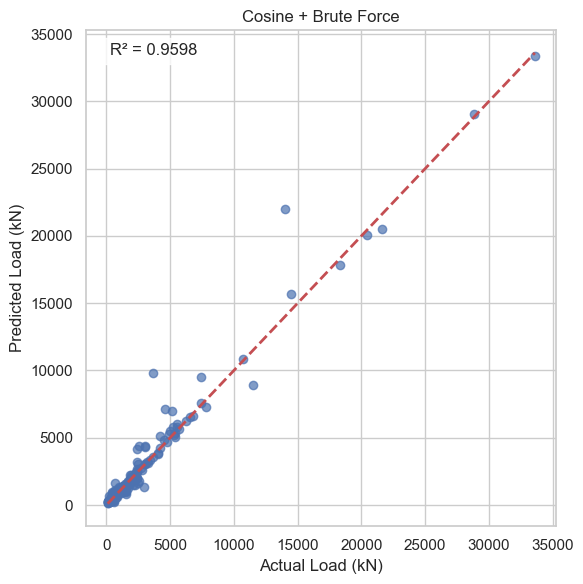

In [30]:
best_k = grid.best_params_["n_neighbors"]
best_weight = grid.best_params_["weights"]

# Covariance matrix
cov_matrix = np.cov(x_train_scaled, rowvar=False)

# Inverse covariance matrix (required by Mahalanobis)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# -------------------------------------------------------
# 7 KNN Variants
# -------------------------------------------------------
models = {
    "Minkowski + KD-Tree":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="minkowski",
            p=2,
            algorithm="kd_tree"
        ),

    "Minkowski + Ball-Tree":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="minkowski",
            p=2,
            algorithm="ball_tree"
        ),

    "Chebyshev + Brute Force":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="chebyshev",
            algorithm="brute"
        ),

    "Chebyshev + KD-Tree":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="chebyshev",
            algorithm="kd_tree"
        ),

    "Chebyshev + Ball-Tree":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="chebyshev",
            algorithm="ball_tree"
        ),

    "Mahalanobis + Brute Force":
    KNeighborsRegressor(
        n_neighbors=best_k,
        weights=best_weight,
        metric="mahalanobis",
        metric_params={"VI": inv_cov_matrix},   # <-- VI, not V
        algorithm="brute"
    ),

    "Cosine + Brute Force":
        KNeighborsRegressor(
            n_neighbors=best_k,
            weights=best_weight,
            metric="cosine",
            algorithm="brute"
        )
}

# -------------------------------------------------------
# Train & Evaluate
# -------------------------------------------------------
results = []

for name, model in models.items():

    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    results.append({
        "Model": name,
        "R2 Score": round(r2_score(y_test, y_pred), 4),
        "RMSE": round(root_mean_squared_error(y_test, y_pred), 3),
        "MAE": round(mean_absolute_error(y_test, y_pred), 3),
        "MAPE (%)": round(mean_absolute_percentage_error(y_test, y_pred)*100, 2)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)


plot_df = results_df.sort_values("R2 Score")

plt.figure(figsize=(10,6))

plt.barh(plot_df["Model"], plot_df["R2 Score"])

plt.xlabel("R² Score", fontsize=12)
plt.ylabel("KNN Variant", fontsize=12)
plt.title("Performance Comparison of 7 KNN Variants", fontsize=14)

plt.xlim(0.85, 1.0)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



# Best performing model
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

best_model.fit(x_train_scaled, y_train)
y_best = best_model.predict(x_test_scaled)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_best, alpha=0.7)

min_val = min(y_test.min(), y_best.min())
max_val = max(y_test.max(), y_best.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--', linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title(f"{best_name}")

plt.text(
    0.05, 0.95,
    f"R² = {r2_score(y_test, y_best):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()

### SVR Model

In [31]:
# SVR Model
from sklearn.svm import SVR

param_grid = {
    "kernel": ["rbf"],
    "C": [1, 10, 50, 100, 500, 1000],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "epsilon": [0.01, 0.05, 0.1, 0.2, 0.5]
}

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(x_train_scaled, y_train)

best_svr = grid_svr.best_estimator_

print("Best Parameters :", grid_svr.best_params_)
print("Best CV R²      :", round(grid_svr.best_score_, 4))

y_svr_train_pred = best_svr.predict(x_train_scaled)
y_svr_pred = best_svr.predict(x_test_scaled)

# evaluation matrix
print(f"r2_score: {r2_score(y_test,y_svr_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test,y_svr_pred)}")
print(f"MAE: {mean_absolute_error(y_test,y_svr_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test,y_svr_pred)}")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best Parameters : {'C': 1000, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV R²      : 0.7186
r2_score: 0.8355357401264558
RMSE: 1634.3371915912956
MAE: 520.778928097612
MAPE: 0.28261835585732026


2 Varients of SVR

In [32]:
from sklearn.svm import NuSVR

# ==========================================================
# MODEL 1 : RBF + ν-SVR (Optimized)
# ==========================================================

param_grid = {
    "kernel": ["rbf"],
    "C": [1, 10, 50, 100, 500],
    "nu": [0.1, 0.25, 0.5, 0.75],
    "gamma": ["scale", 0.001, 0.01, 0.1]
}

grid_nusvr = GridSearchCV(
    estimator=NuSVR(),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_nusvr.fit(x_train_scaled, y_train)

best_nusvr = grid_nusvr.best_estimator_

print("="*55)
print("Best Parameters :", grid_nusvr.best_params_)
print("Best CV R²      :", round(grid_nusvr.best_score_, 4))
print("="*55)

# Prediction
y_nusvr_train = best_nusvr.predict(x_train_scaled)
y_nusvr_pred = best_nusvr.predict(x_test_scaled)

# ==========================================================
# MODEL 2 : RBF + ν-SVR + Fuzzy SVR
# ==========================================================

fuzzy_model = NuSVR(
    kernel="rbf",
    C=best_nusvr.C,
    nu=best_nusvr.nu,
    gamma=best_nusvr.gamma
)

# Initial equal memberships
weights = np.ones(len(y_train))

# Iterative residual-based fuzzy learning
for _ in range(5):

    fuzzy_model.fit(
        x_train_scaled,
        y_train,
        sample_weight=weights
    )

    pred_train = fuzzy_model.predict(x_train_scaled)

    residual = np.abs(y_train - pred_train)

    sigma = np.std(residual)

    # Gaussian fuzzy membership
    weights = np.exp(-(residual**2)/(2*sigma**2))

# Final prediction
y_fuzzy_train = fuzzy_model.predict(x_train_scaled)
y_fuzzy_pred = fuzzy_model.predict(x_test_scaled)

# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model_name, y_true, y_pred):

    return {
        "Model": model_name,
        "R2 Score": round(r2_score(y_true, y_pred), 4),
        "RMSE": round(root_mean_squared_error(y_true, y_pred), 3),
        "MAE": round(mean_absolute_error(y_true, y_pred), 3),
        "MAPE (%)": round(mean_absolute_percentage_error(y_true, y_pred)*100, 2)
    }

# ==========================================================
# RESULTS
# ==========================================================

results = [
    evaluate_model("RBF + ν-SVR", y_test, y_nusvr_pred),
    evaluate_model("RBF + ν-SVR + Fuzzy SVR", y_test, y_fuzzy_pred)
]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\n================ SVR VARIANT COMPARISON ================\n")
print(results_df.to_string(index=False))



Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters : {'C': 500, 'gamma': 0.01, 'kernel': 'rbf', 'nu': 0.25}
Best CV R²      : 0.6417

================ SVR VARIANT COMPARISON ================

                  Model  R2 Score     RMSE     MAE  MAPE (%)
            RBF + ν-SVR     0.774 1915.998 627.019     33.79
RBF + ν-SVR + Fuzzy SVR     0.460 2961.312 858.159     35.05


### Tree Model

In [52]:
# Tree Model
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_tree.fit(x_train_scaled, y_train)

best_tree = grid_tree.best_estimator_

print("Best Parameters :", grid_tree.best_params_)
print("Best CV R²      :", round(grid_tree.best_score_, 4))

y_tree_train_pred = best_tree.predict(x_train_scaled)
y_tree_pred = best_tree.predict(x_test_scaled)

# evaluation matrix
print(f"r2_score: {r2_score(y_test,y_svr_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test,y_svr_pred)}")
print(f"MAE: {mean_absolute_error(y_test,y_svr_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test,y_svr_pred)}")

Fitting 5 folds for each of 672 candidates, totalling 3360 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
1680 fits failed out of a total of 3360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
403 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 554, in _validat

Best Parameters : {'criterion': 'squared_error', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R²      : 0.9407
r2_score: 0.8355357401264558
RMSE: 1634.3371915912956
MAE: 520.778928097612
MAPE: 0.28261835585732026



============= 12 TREE VARIANT COMPARISON =============

                   Model  R2 Score     RMSE     MAE  MAPE (%)
           CatBoost (L2)    0.9808  558.285 243.392     17.89
            XGBoost (L2)    0.9788  586.570 217.286     14.36
           CatBoost (L1)    0.9720  674.135 257.576     16.90
  LightGBM Constant (L2)    0.9697  701.982 270.277     14.88
      Random Forest (L1)    0.9689  710.854 267.602     15.73
        Extra Trees (L1)    0.9687  713.433 234.603     13.93
        Extra Trees (L2)    0.9686  713.635 259.313     19.02
      Random Forest (L2)    0.9661  741.666 268.166     15.13
            XGBoost (L1)    0.9371 1010.325 307.799     15.78
  LightGBM Constant (L1)    0.9317 1052.955 339.113     15.10
    LightGBM Linear (L2)    0.9069 1229.530 412.188     32.25
LightGBM Linear (Robust)    0.8805 1393.076 338.160     15.85


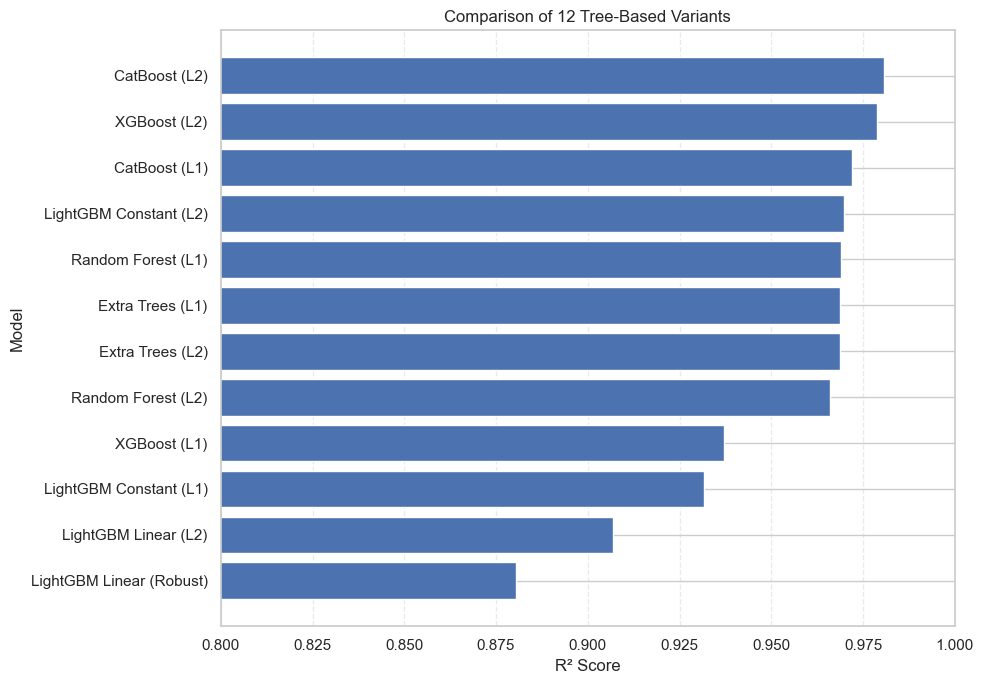

In [34]:
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "R2 Score": round(r2_score(y_true, y_pred),4),
        "RMSE": round(root_mean_squared_error(y_true, y_pred),3),
        "MAE": round(mean_absolute_error(y_true, y_pred),3),
        "MAPE (%)": round(mean_absolute_percentage_error(y_true, y_pred)*100,2)
    }

results = []

# ==========================================================
# Common Hyperparameter Grid
# ==========================================================

tree_grid = {
    "n_estimators":[200],
    "max_depth":[10,15,None],
    "min_samples_leaf":[1,2,4]
}

# ==========================================================
# 1–2 Random Forest
# ==========================================================

rf_l2 = GridSearchCV(
    RandomForestRegressor(
        criterion="squared_error",
        random_state=42
    ),
    tree_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

rf_l2.fit(x_train_scaled, y_train)
pred = rf_l2.best_estimator_.predict(x_test_scaled)
results.append(evaluate_model("Random Forest (L2)", y_test, pred))

rf_l1 = GridSearchCV(
    RandomForestRegressor(
        criterion="absolute_error",
        random_state=42
    ),
    tree_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

rf_l1.fit(x_train_scaled, y_train)
pred = rf_l1.best_estimator_.predict(x_test_scaled)
results.append(evaluate_model("Random Forest (L1)", y_test, pred))

# ==========================================================
# 3–4 Extra Trees
# ==========================================================

et_l2 = GridSearchCV(
    ExtraTreesRegressor(
        criterion="squared_error",
        random_state=42
    ),
    tree_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

et_l2.fit(x_train_scaled, y_train)
pred = et_l2.best_estimator_.predict(x_test_scaled)
results.append(evaluate_model("Extra Trees (L2)", y_test, pred))

et_l1 = GridSearchCV(
    ExtraTreesRegressor(
        criterion="absolute_error",
        random_state=42
    ),
    tree_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

et_l1.fit(x_train_scaled, y_train)
pred = et_l1.best_estimator_.predict(x_test_scaled)
results.append(evaluate_model("Extra Trees (L1)", y_test, pred))

# ==========================================================
# 5–6 XGBoost
# ==========================================================

for obj, name in [
    ("reg:squarederror","XGBoost (L2)"),
    ("reg:absoluteerror","XGBoost (L1)")
]:

    model = XGBRegressor(
        objective=obj,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    results.append(evaluate_model(name, y_test, pred))

# ==========================================================
# 7–8 CatBoost
# ==========================================================

for loss, name in [
    ("RMSE","CatBoost (L2)"),
    ("MAE","CatBoost (L1)")
]:

    model = CatBoostRegressor(
        loss_function=loss,
        iterations=500,
        depth=6,
        learning_rate=0.05,
        verbose=0,
        random_seed=42
    )

    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    results.append(evaluate_model(name, y_test, pred))

# ==========================================================
# 9–10 LightGBM (Constant Leaf)
# ==========================================================

for obj, name in [
    ("regression","LightGBM Constant (L2)"),
    ("regression_l1","LightGBM Constant (L1)")
]:

    model = LGBMRegressor(
        objective=obj,
        linear_tree=False,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    results.append(evaluate_model(name, y_test, pred))


# ==========================================================
# 11. LightGBM Linear Leaf (L2)
# ==========================================================

model = LGBMRegressor(
    objective="regression",
    linear_tree=True,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model.fit(x_train_scaled, y_train)

pred = model.predict(x_test_scaled)

results.append(
    evaluate_model(
        "LightGBM Linear (L2)",
        y_test,
        pred
    )
)

# ==========================================================
# 12. LightGBM Linear Leaf (Pseudo L1)
# ==========================================================
# Linear trees do not support regression_l1.
# We use regression with a robust configuration.

model = LGBMRegressor(
    objective="regression",
    linear_tree=True,
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)

model.fit(x_train_scaled, y_train)

pred = model.predict(x_test_scaled)

results.append(
    evaluate_model(
        "LightGBM Linear (Robust)",
        y_test,
        pred
    )
)
# ==========================================================
# Final Comparison Table
# ==========================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\n============= 12 TREE VARIANT COMPARISON =============\n")
print(results_df.to_string(index=False))


plot_df = results_df.sort_values("R2 Score")

plt.figure(figsize=(10,7))

plt.barh(plot_df["Model"], plot_df["R2 Score"])

plt.xlabel("R² Score")
plt.ylabel("Model")
plt.title("Comparison of 12 Tree-Based Variants")

plt.xlim(0.80,1.00)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Evaluation

In [35]:
# Evaluation Table
print("Evaluation score for training data:")
def evaluate_model(model_name, y_test, y_pred):
    return {
        "Model": model_name,
        "R2 Score": r2_score(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
    }
models_eval = [
    evaluate_model("KNN", y_train, yk_train_pred),
    evaluate_model("SVR", y_train, y_svr_train_pred),
    evaluate_model("Decision Tree", y_train, y_tree_train_pred)
]
metrics_train_df = pd.DataFrame(models_eval)
print(metrics_train_df)

print("\n Evaluation score for testing data:")

def evaluate_model(model_name, y_test, y_pred):
    return {
        "Model": model_name,
        "R2 Score": r2_score(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
    }
models_eval = [
    evaluate_model("KNN", y_test, yk_pred),
    evaluate_model("SVR", y_test, y_svr_pred),
    evaluate_model("Decision Tree", y_test, y_tree_pred)
]
metrics_df = pd.DataFrame(models_eval)
print(metrics_df)

Evaluation score for training data:
           Model  R2 Score         RMSE         MAE      MAPE
0            KNN  0.999115   153.425503   45.238909  0.042954
1            SVR  0.723186  2714.173045  692.063719  0.323915
2  Decision Tree  0.998029   229.032797  131.497242  0.140943

 Evaluation score for testing data:
           Model  R2 Score         RMSE         MAE      MAPE
0            KNN  0.947103   926.872987  289.749797  0.156276
1            SVR  0.835536  1634.337192  520.778928  0.282618
2  Decision Tree  0.958553   820.455257  316.264831  0.192086


### Plot of the BASE MODELS

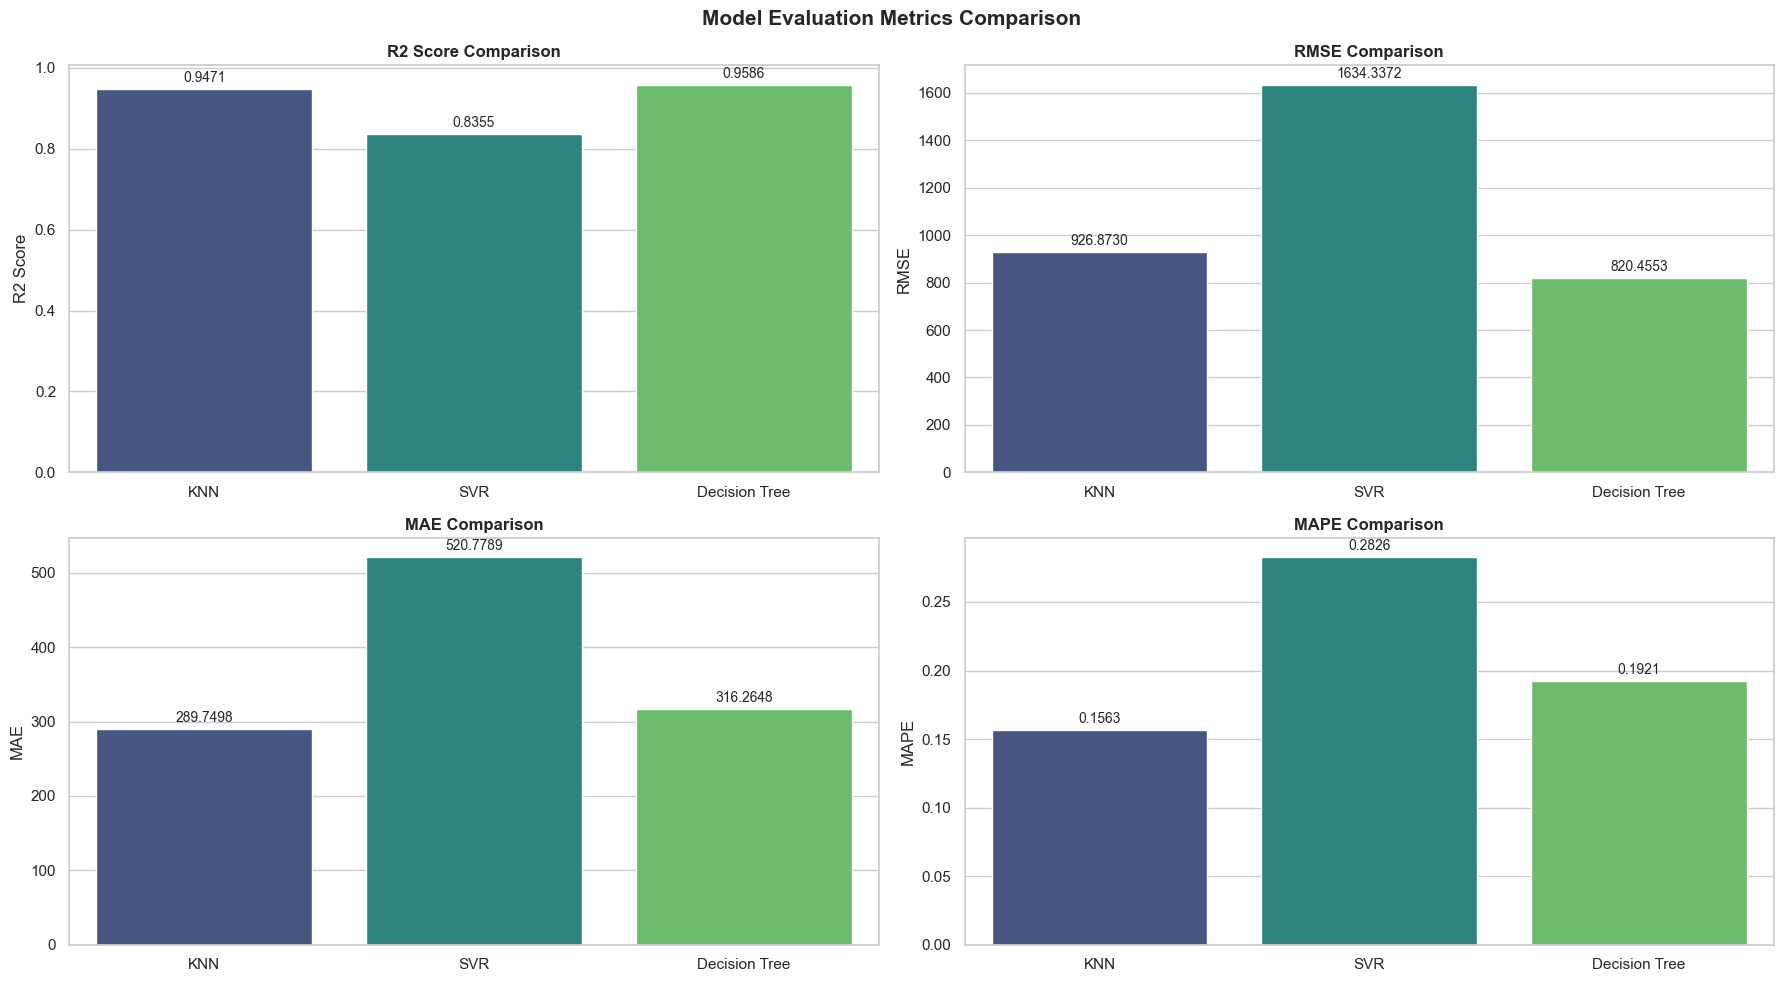

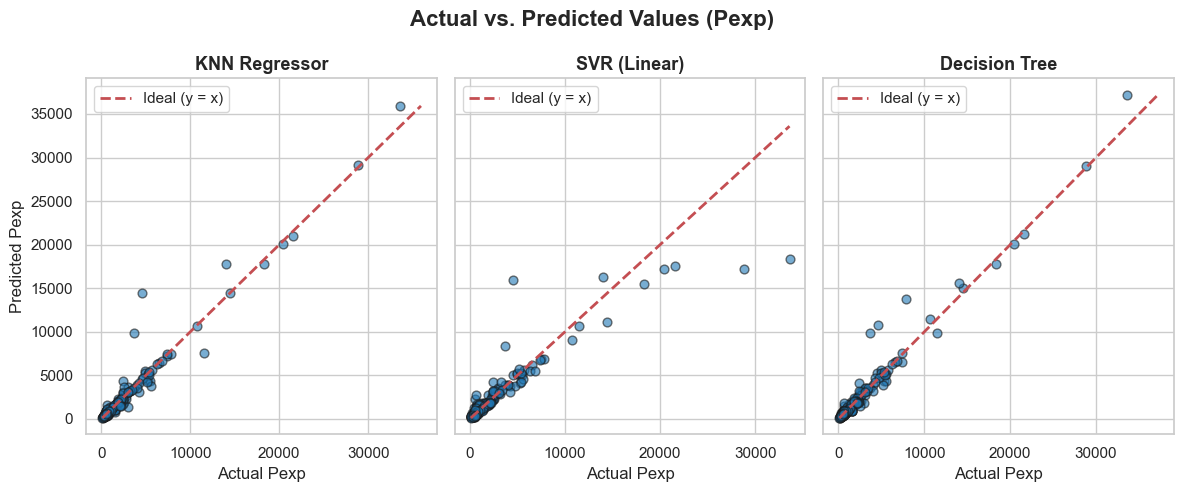

In [36]:
sns.set_theme(style="whitegrid")

# Graph 1: Metrics Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Model Evaluation Metrics Comparison", fontsize=15, fontweight="bold")

metrics = ["R2 Score", "RMSE", "MAE", "MAPE"]

for idx, metric in enumerate(metrics):
  ax = axes[idx // 2, idx % 2]
  sns.barplot(
      data=metrics_df,
      x="Model",
      y=metric,
      ax=ax,
      palette="viridis",
      hue="Model",
      legend=False,
  )
  ax.set_title(f"{metric} Comparison", fontsize=12, fontweight="bold")
  ax.set_xlabel("")
  ax.set_ylabel(metric)

  for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

# Graph 2: Actual vs. Predicted Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
fig.suptitle("Actual vs. Predicted Values (Pexp)", fontsize=16, fontweight="bold")

models_preds = [
    ("KNN Regressor", yk_pred),
    ("SVR (Linear)", y_svr_pred),
    ("Decision Tree", y_tree_pred),
]

for idx, (name, y_pred) in enumerate(models_preds):
  ax = axes[idx]
  ax.scatter(y_test, y_pred, alpha=0.6, color="#1f77b4", edgecolors="k", s=40)

  min_val = min(y_test.min(), y_pred.min())
  max_val = max(y_test.max(), y_pred.max())
  ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Ideal (y = x)")

  ax.set_title(name, fontsize=13, fontweight="bold")
  ax.set_xlabel("Actual Pexp")
  if idx == 0:
    ax.set_ylabel("Predicted Pexp")
  ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


# Best Model CatBoost [L2]

        Model  R2 Score    RMSE     MAE  MAPE (%)
CatBoost (L2)    0.9808 558.285 243.392     17.89


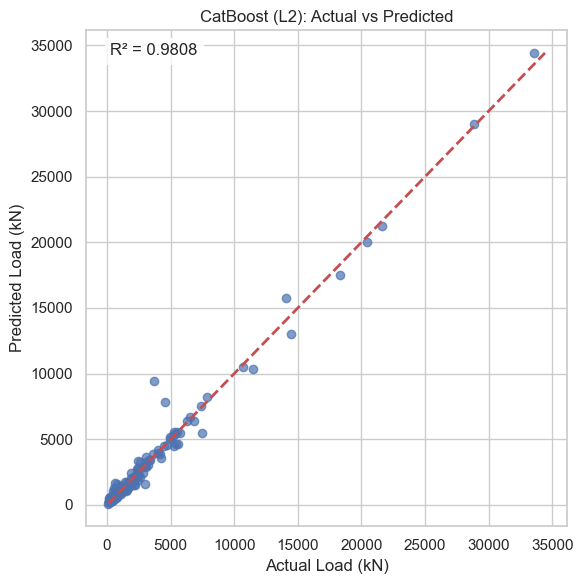

In [37]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=500,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_model.fit(x_train_scaled, y_train)

# Prediction
y_cat_train = cat_model.predict(x_train_scaled)
y_cat_pred = cat_model.predict(x_test_scaled)

# ==========================================================
# Evaluation
# ==========================================================

cat_results = pd.DataFrame({
    "Model": ["CatBoost (L2)"],
    "R2 Score": [round(r2_score(y_test, y_cat_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_cat_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_cat_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_cat_pred)*100,2)]
})

print(cat_results.to_string(index=False))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_cat_pred, alpha=0.7)

min_val = min(y_test.min(), y_cat_pred.min())
max_val = max(y_test.max(), y_cat_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("CatBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_cat_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()

# 2nd Best Model- XG Boost [L2]

       Model  R2 Score   RMSE     MAE  MAPE (%)
XGBoost (L2)    0.9788 586.57 217.286     14.36


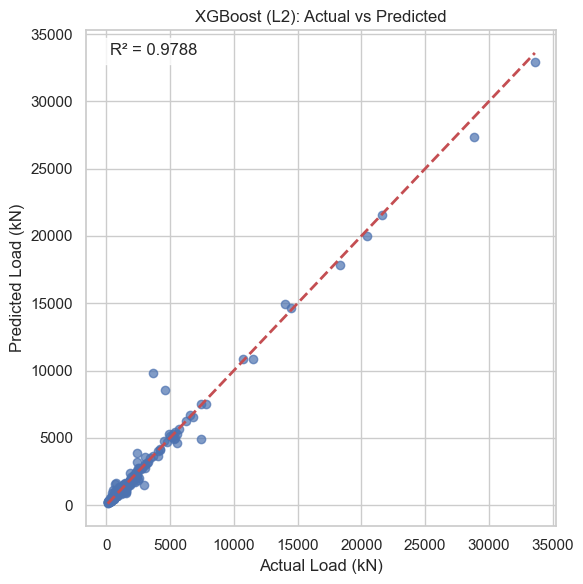

In [38]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train)

# Prediction
y_xgb_train = xgb_model.predict(x_train_scaled)
y_xgb_pred = xgb_model.predict(x_test_scaled)

# ==========================================================
# Evaluation
# ==========================================================

xgb_results = pd.DataFrame({
    "Model": ["XGBoost (L2)"],
    "R2 Score": [round(r2_score(y_test, y_xgb_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_xgb_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_xgb_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_xgb_pred)*100,2)]
})

print(xgb_results.to_string(index=False))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_xgb_pred, alpha=0.7)

min_val = min(y_test.min(), y_xgb_pred.min())
max_val = max(y_test.max(), y_xgb_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("XGBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_xgb_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()

# Comparison of the best 2 Models

           Model  R2 Score     RMSE      MAE  MAPE (%)
0  CatBoost (L2)    0.9808  558.285  243.392     17.89
1   XGBoost (L2)    0.9788  586.570  217.286     14.36


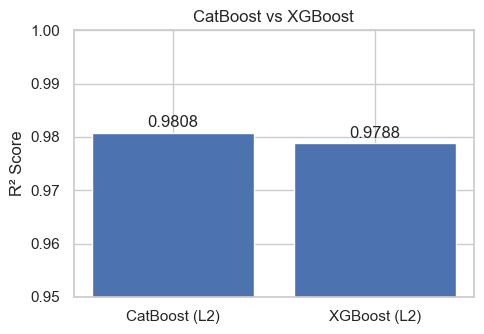

In [39]:
comparison = pd.concat([cat_results, xgb_results], ignore_index=True)

print(comparison)

plt.figure(figsize=(5,3.5))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.ylabel("R² Score")
plt.title("CatBoost vs XGBoost")
plt.ylim(0.95, 1.00)

for i, v in enumerate(comparison["R2 Score"]):
    plt.text(i, v+0.001, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

## Imports


In [40]:
import mealpy
print(mealpy.__version__) # 3.0.3


3.0.3


## KNN

In [41]:
from mealpy import FloatVar
from mealpy.evolutionary_based import FPA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *

metrics = [
    ("euclidean","kd_tree"),
    ("euclidean","ball_tree"),
    ("chebyshev","brute"),
    ("chebyshev","kd_tree"),
    ("chebyshev","ball_tree"),
    ("mahalanobis","brute"),
    ("cosine","brute")
]

cov = np.cov(x_train_scaled, rowvar=False)
VI = np.linalg.pinv(cov)

fpa_results = []

for metric, algo in metrics:

    def objective(sol):
        k = max(2, int(round(sol[0])))
        w = "uniform" if sol[1] < 0.5 else "distance"

        if metric == "mahalanobis":
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                metric_params={"VI":VI},
                algorithm=algo
            )
        else:
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                algorithm=algo
            )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(lb=(2,0), ub=(20,1)),
        "minmax":"min"
    }

    optimizer = FPA.OriginalFPA(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    k = int(round(best.solution[0]))
    w = "uniform" if best.solution[1] < 0.5 else "distance"

    if metric == "mahalanobis":
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            metric_params={"VI":VI},
            algorithm=algo
        )
    else:
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            algorithm=algo
        )

    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    fpa_results.append({
        "Optimizer":"FPA",
        "Variant":f"{metric} + {algo}",
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

fpa_knn = pd.DataFrame(fpa_results).sort_values("R2", ascending=False)
print(fpa_knn)

2026/09/02 03:26:42 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: OriginalFPA(epoch=40, pop_size=30, p_s=0.8, levy_multiplier=0.1)
2026/09/02 03:26:43 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 1, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 0.77954 seconds
2026/09/02 03:26:45 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 2, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 1.17517 seconds
2026/09/02 03:26:45 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 3, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 0.86367 seconds
2026/09/02 03:26:47 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 4, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 1.34317 seconds
2026/09/02 03:26:48 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch:

  Optimizer                Variant        R2         RMSE         MAE  \
3       FPA    chebyshev + kd_tree  0.947983   919.131508  344.089270   
4       FPA  chebyshev + ball_tree  0.947649   922.082135  344.594235   
2       FPA      chebyshev + brute  0.947143   926.522522  352.106407   
5       FPA    mahalanobis + brute  0.943294   959.665900  324.121260   
1       FPA  euclidean + ball_tree  0.941540   974.391450  312.837378   
0       FPA    euclidean + kd_tree  0.941530   974.480356  313.081781   
6       FPA         cosine + brute  0.935442  1023.954847  317.623745   

        MAPE  
3  21.628449  
4  21.582568  
2  22.251162  
5  16.416203  
1  18.234966  
0  18.341160  
6  17.749969  


In [42]:
from mealpy.bio_based import SMA

sma_results = []

for metric, algo in metrics:

    def objective(sol):
        k = max(2, int(round(sol[0])))
        w = "uniform" if sol[1] < 0.5 else "distance"

        if metric == "mahalanobis":
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                metric_params={"VI":VI},
                algorithm=algo
            )
        else:
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                algorithm=algo
            )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(lb=(2,0), ub=(20,1)),
        "minmax":"min"
    }

    optimizer = SMA.OriginalSMA(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    k = int(round(best.solution[0]))
    w = "uniform" if best.solution[1] < 0.5 else "distance"

    if metric == "mahalanobis":
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            metric_params={"VI":VI},
            algorithm=algo
        )
    else:
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            algorithm=algo
        )

    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    sma_results.append({
        "Optimizer":"SMA",
        "Variant":f"{metric} + {algo}",
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sma_knn = pd.DataFrame(sma_results).sort_values("R2", ascending=False)
print(sma_knn)

2026/09/02 03:31:12 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: OriginalSMA(epoch=40, pop_size=30, p_t=0.03)
2026/09/02 03:31:13 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 1, Current best: -0.9393206206829945, Global best: -0.9500946653608722, Runtime: 0.80012 seconds
2026/09/02 03:31:14 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 2, Current best: -0.9393206206829945, Global best: -0.9500946653608722, Runtime: 0.64655 seconds
2026/09/02 03:31:15 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 3, Current best: -0.9314937358695488, Global best: -0.9500946653608722, Runtime: 0.77507 seconds
2026/09/02 03:31:16 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 4, Current best: -0.9393206206829945, Global best: -0.9500946653608722, Runtime: 0.69383 seconds
2026/09/02 03:31:16 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 5, Current best: -0.9393206206829945, Global best: -0.9500946653608722, R

  Optimizer                Variant        R2        RMSE         MAE  \
3       SMA    chebyshev + kd_tree  0.947983  919.131508  344.089270   
4       SMA  chebyshev + ball_tree  0.947649  922.082135  344.594235   
2       SMA      chebyshev + brute  0.947143  926.522522  352.106407   
6       SMA         cosine + brute  0.944633  948.268761  304.524368   
5       SMA    mahalanobis + brute  0.943294  959.665900  324.121260   
1       SMA  euclidean + ball_tree  0.941540  974.391450  312.837378   
0       SMA    euclidean + kd_tree  0.941530  974.480356  313.081781   

        MAPE  
3  21.628449  
4  21.582568  
2  22.251162  
6  17.451392  
5  16.416203  
1  18.234966  
0  18.341160  


In [43]:
from mealpy.bio_based import SOS

sos_results = []

for metric, algo in metrics:

    def objective(sol):
        k = max(2, int(round(sol[0])))
        w = "uniform" if sol[1] < 0.5 else "distance"

        if metric == "mahalanobis":
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                metric_params={"VI":VI},
                algorithm=algo
            )
        else:
            model = KNeighborsRegressor(
                n_neighbors=k,
                weights=w,
                metric=metric,
                algorithm=algo
            )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(lb=(2,0), ub=(20,1)),
        "minmax":"min"
    }

    optimizer = SOS.OriginalSOS(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    k = int(round(best.solution[0]))
    w = "uniform" if best.solution[1] < 0.5 else "distance"

    if metric == "mahalanobis":
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            metric_params={"VI":VI},
            algorithm=algo
        )
    else:
        final = KNeighborsRegressor(
            n_neighbors=k,
            weights=w,
            metric=metric,
            algorithm=algo
        )

    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    sos_results.append({
        "Optimizer":"SOS",
        "Variant":f"{metric} + {algo}",
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sos_knn = pd.DataFrame(sos_results).sort_values("R2", ascending=False)
print(sos_knn)

2026/09/02 03:35:32 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: OriginalSOS(epoch=40, pop_size=30)
2026/09/02 03:35:36 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 1, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 3.52355 seconds
2026/09/02 03:35:40 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 2, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 3.50597 seconds
2026/09/02 03:35:42 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 3, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 2.48398 seconds
2026/09/02 03:35:45 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 4, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 2.52942 seconds
2026/09/02 03:35:48 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 5, Current best: -0.9500946653608722, Global best: -0.9500946653608722, Runtime: 3.

  Optimizer                Variant        R2         RMSE         MAE  \
3       SOS    chebyshev + kd_tree  0.947983   919.131508  344.089270   
4       SOS  chebyshev + ball_tree  0.947649   922.082135  344.594235   
2       SOS      chebyshev + brute  0.947143   926.522522  352.106407   
5       SOS    mahalanobis + brute  0.943294   959.665900  324.121260   
1       SOS  euclidean + ball_tree  0.941540   974.391450  312.837378   
0       SOS    euclidean + kd_tree  0.941530   974.480356  313.081781   
6       SOS         cosine + brute  0.935442  1023.954847  317.623745   

        MAPE  
3  21.628449  
4  21.582568  
2  22.251162  
5  16.416203  
1  18.234966  
0  18.341160  
6  17.749969  


## SVR

In [44]:
from mealpy import FloatVar
from mealpy.evolutionary_based import FPA
from sklearn.svm import NuSVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *
import pandas as pd
import numpy as np

fpa_svr_results = []

# -------------------------------------------------------
# Both SVR Variants
# -------------------------------------------------------
variants = [
    ("RBF + ν-SVR", False),
    ("RBF + ν-SVR + Fuzzy SVR", True)
]

for name, fuzzy in variants:

    def objective(sol):
        C = float(sol[0])
        nu = float(sol[1])
        gamma = float(sol[2])

        model = NuSVR(
            kernel="rbf",
            C=C,
            nu=nu,
            gamma=gamma
        )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(
            lb=(1,0.05,0.001),
            ub=(500,0.8,0.1)
        ),
        "minmax":"min"
    }

    optimizer = FPA.OriginalFPA(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    C = float(best.solution[0])
    nu = float(best.solution[1])
    gamma = float(best.solution[2])

    model = NuSVR(
        kernel="rbf",
        C=C,
        nu=nu,
        gamma=gamma
    )

    # ---------- Fuzzy SVR ----------
    if fuzzy:

        weights = np.ones(len(y_train))

        for _ in range(5):

            model.fit(
                x_train_scaled,
                y_train,
                sample_weight=weights
            )

            pred = model.predict(x_train_scaled)

            residual = np.abs(y_train-pred)

            sigma = np.std(residual)

            weights = np.exp(
                -(residual**2)/(2*sigma**2)
            )

    model.fit(
        x_train_scaled,
        y_train
    )

    pred = model.predict(x_test_scaled)

    fpa_svr_results.append({
        "Optimizer":"FPA",
        "Variant":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

fpa_svr = pd.DataFrame(fpa_svr_results)

print(fpa_svr)

2026/09/02 03:55:06 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: OriginalFPA(epoch=40, pop_size=30, p_s=0.8, levy_multiplier=0.1)
2026/09/02 03:55:15 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 1, Current best: -0.5594937059568419, Global best: -0.5594937059568419, Runtime: 4.86985 seconds
2026/09/02 03:55:20 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 2, Current best: -0.5678819559117535, Global best: -0.5678819559117535, Runtime: 4.75172 seconds
2026/09/02 03:55:25 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 3, Current best: -0.5678819559117535, Global best: -0.5678819559117535, Runtime: 5.26146 seconds
2026/09/02 03:55:33 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 4, Current best: -0.5678819559117535, Global best: -0.5678819559117535, Runtime: 7.57872 seconds
2026/09/02 03:55:38 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch:

  Optimizer                  Variant        R2         RMSE         MAE  \
0       FPA              RBF + ν-SVR  0.768096  1940.708387  630.623307   
1       FPA  RBF + ν-SVR + Fuzzy SVR  0.779626  1891.849183  641.419021   

        MAPE  
0  34.013555  
1  34.210921  


In [45]:
from mealpy.bio_based import SMA

sma_svr_results = []

variants = [
    ("RBF + ν-SVR", False),
    ("RBF + ν-SVR + Fuzzy SVR", True)
]

for name, fuzzy in variants:

    def objective(sol):

        model = NuSVR(
            kernel="rbf",
            C=float(sol[0]),
            nu=float(sol[1]),
            gamma=float(sol[2])
        )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(
            lb=(1,0.05,0.001),
            ub=(500,0.8,0.1)
        ),
        "minmax":"min"
    }

    optimizer = SMA.OriginalSMA(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    model = NuSVR(
        kernel="rbf",
        C=float(best.solution[0]),
        nu=float(best.solution[1]),
        gamma=float(best.solution[2])
    )

    if fuzzy:

        weights = np.ones(len(y_train))

        for _ in range(5):

            model.fit(
                x_train_scaled,
                y_train,
                sample_weight=weights
            )

            pred = model.predict(x_train_scaled)

            residual = np.abs(y_train-pred)

            sigma = np.std(residual)

            weights = np.exp(
                -(residual**2)/(2*sigma**2)
            )

    model.fit(x_train_scaled,y_train)

    pred = model.predict(x_test_scaled)

    sma_svr_results.append({
        "Optimizer":"SMA",
        "Variant":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sma_svr = pd.DataFrame(sma_svr_results)

print(sma_svr)

2026/09/02 04:01:59 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: OriginalSMA(epoch=40, pop_size=30, p_t=0.03)
2026/09/02 04:02:08 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 1, Current best: -0.37800821354957126, Global best: -0.544787121232283, Runtime: 3.64181 seconds
2026/09/02 04:02:13 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 2, Current best: -0.6209599061590466, Global best: -0.6209599061590466, Runtime: 4.87203 seconds
2026/09/02 04:02:18 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 3, Current best: -0.6444247183189382, Global best: -0.6444247183189382, Runtime: 4.68307 seconds
2026/09/02 04:02:22 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 4, Current best: -0.6493496968667276, Global best: -0.6493496968667276, Runtime: 4.38315 seconds
2026/09/02 04:02:26 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 5, Current best: -0.6513572794786866, Global best: -0.6513572794786866, R

  Optimizer                  Variant        R2         RMSE         MAE  \
0       SMA              RBF + ν-SVR  0.780053  1890.014453  636.708681   
1       SMA  RBF + ν-SVR + Fuzzy SVR  0.780241  1889.206419  638.602877   

        MAPE  
0  33.879549  
1  34.062361  


In [46]:
from mealpy.bio_based import SOS

sos_svr_results = []

variants = [
    ("RBF + ν-SVR", False),
    ("RBF + ν-SVR + Fuzzy SVR", True)
]

for name, fuzzy in variants:

    def objective(sol):

        model = NuSVR(
            kernel="rbf",
            C=float(sol[0]),
            nu=float(sol[1]),
            gamma=float(sol[2])
        )

        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": FloatVar(
            lb=(1,0.05,0.001),
            ub=(500,0.8,0.1)
        ),
        "minmax":"min"
    }

    optimizer = SOS.OriginalSOS(epoch=40, pop_size=30)
    best = optimizer.solve(problem)

    model = NuSVR(
        kernel="rbf",
        C=float(best.solution[0]),
        nu=float(best.solution[1]),
        gamma=float(best.solution[2])
    )

    if fuzzy:

        weights = np.ones(len(y_train))

        for _ in range(5):

            model.fit(
                x_train_scaled,
                y_train,
                sample_weight=weights
            )

            pred = model.predict(x_train_scaled)

            residual = np.abs(y_train-pred)

            sigma = np.std(residual)

            weights = np.exp(
                -(residual**2)/(2*sigma**2)
            )

    model.fit(x_train_scaled,y_train)

    pred = model.predict(x_test_scaled)

    sos_svr_results.append({
        "Optimizer":"SOS",
        "Variant":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sos_svr = pd.DataFrame(sos_svr_results)

print(sos_svr)

2026/09/02 04:06:02 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: OriginalSOS(epoch=40, pop_size=30)
2026/09/02 04:06:32 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 1, Current best: -0.6278419966763302, Global best: -0.6278419966763302, Runtime: 24.05105 seconds
2026/09/02 04:06:58 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 2, Current best: -0.6424553149384596, Global best: -0.6424553149384596, Runtime: 26.32866 seconds
2026/09/02 04:07:26 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 3, Current best: -0.6500002961464225, Global best: -0.6500002961464225, Runtime: 27.67968 seconds
2026/09/02 04:07:49 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 4, Current best: -0.6519489908634356, Global best: -0.6519489908634356, Runtime: 23.19184 seconds
2026/09/02 04:08:11 PM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 5, Current best: -0.6522837393667321, Global best: -0.6522837393667321, Runtime

  Optimizer                  Variant        R2         RMSE         MAE  \
0       SOS              RBF + ν-SVR  0.780046  1890.043779  636.684897   
1       SOS  RBF + ν-SVR + Fuzzy SVR  0.780045  1890.046359  636.684085   

        MAPE  
0  33.877740  
1  33.877634  


## Trees

In [49]:
from mealpy import FloatVar
from mealpy.evolutionary_based import FPA
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import pandas as pd

fpa_tree_results = []

# -------------------------------------------------------
# Model Builders
# -------------------------------------------------------
models = {

"Random Forest (L2)": lambda p: RandomForestRegressor(
    criterion="squared_error",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    min_samples_leaf=int(p[2]),
    random_state=42
),

"Random Forest (L1)": lambda p: RandomForestRegressor(
    criterion="absolute_error",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    min_samples_leaf=int(p[2]),
    random_state=42
),

"Extra Trees (L2)": lambda p: ExtraTreesRegressor(
    criterion="squared_error",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    min_samples_leaf=int(p[2]),
    random_state=42
),

"Extra Trees (L1)": lambda p: ExtraTreesRegressor(
    criterion="absolute_error",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    min_samples_leaf=int(p[2]),
    random_state=42
),

"XGBoost (L2)": lambda p: XGBRegressor(
    objective="reg:squarederror",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    learning_rate=p[2],
    subsample=p[3],
    colsample_bytree=p[4],
    random_state=42
),

"XGBoost (L1)": lambda p: XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=int(p[0]),
    max_depth=int(p[1]),
    learning_rate=p[2],
    subsample=p[3],
    colsample_bytree=p[4],
    random_state=42
),

"CatBoost (L2)": lambda p: CatBoostRegressor(
    loss_function="RMSE",
    iterations=int(p[0]),
    depth=int(p[1]),
    learning_rate=p[2],
    l2_leaf_reg=p[3],
    verbose=0,
    random_seed=42
),

"CatBoost (L1)": lambda p: CatBoostRegressor(
    loss_function="MAE",
    iterations=int(p[0]),
    depth=int(p[1]),
    learning_rate=p[2],
    l2_leaf_reg=p[3],
    verbose=0,
    random_seed=42
),

"LightGBM Constant (L2)": lambda p: LGBMRegressor(
    objective="regression",
    n_estimators=int(p[0]),
    num_leaves=int(p[1]),
    learning_rate=p[2],
    random_state=42,
    verbose=-1
),

"LightGBM Constant (L1)": lambda p: LGBMRegressor(
    objective="regression_l1",
    n_estimators=int(p[0]),
    num_leaves=int(p[1]),
    learning_rate=p[2],
    random_state=42,
    verbose=-1
),

"LightGBM Linear (L2)": lambda p: LGBMRegressor(
    objective="regression",
    linear_tree=True,
    n_estimators=int(p[0]),
    num_leaves=int(p[1]),
    learning_rate=p[2],
    random_state=42,
    verbose=-1
),

"LightGBM Linear (Robust)": lambda p: LGBMRegressor(
    objective="regression",
    linear_tree=True,
    n_estimators=int(p[0]),
    num_leaves=int(p[1]),
    learning_rate=p[2],
    random_state=42,
    verbose=-1
)

}

# -------------------------------------------------------
# Optimization Loop
# -------------------------------------------------------

for name, builder in models.items():

    if "Random" in name or "Extra" in name:
        bounds = FloatVar(lb=(100,5,1), ub=(400,20,5))

    elif "XGBoost" in name:
        bounds = FloatVar(lb=(100,3,0.01,0.5,0.5),
                          ub=(500,10,0.30,1.0,1.0))

    elif "CatBoost" in name:
        bounds = FloatVar(lb=(200,4,0.01,1),
                          ub=(700,10,0.30,10))

    else:
        bounds = FloatVar(lb=(100,10,0.01),
                          ub=(500,60,0.30))

    def objective(sol):
        model = builder(sol)
        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": bounds,
        "minmax": "min"
    }

    optimizer = FPA.OriginalFPA(epoch=10, pop_size=12)
    best = optimizer.solve(problem)

    final = builder(best.solution)
    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    fpa_tree_results.append({
        "Optimizer":"FPA",
        "Model":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

fpa_tree = pd.DataFrame(fpa_tree_results).sort_values("R2", ascending=False)
print(fpa_tree)

2026/09/02 09:29:29 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: OriginalFPA(epoch=10, pop_size=12, p_s=0.8, levy_multiplier=0.1)
2026/09/02 09:30:55 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 1, Current best: -0.9388411887603528, Global best: -0.9388411887603528, Runtime: 41.63879 seconds
2026/09/02 09:31:30 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 2, Current best: -0.9388411887603528, Global best: -0.9388411887603528, Runtime: 34.65922 seconds
2026/09/02 09:32:05 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 3, Current best: -0.9388411887603528, Global best: -0.9388411887603528, Runtime: 35.13789 seconds
2026/09/02 09:32:41 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoch: 4, Current best: -0.939583847389802, Global best: -0.939583847389802, Runtime: 36.33333 seconds
2026/09/02 09:33:18 PM, INFO, mealpy.evolutionary_based.FPA.OriginalFPA: >>>Problem: P, Epoc

   Optimizer                     Model        R2        RMSE         MAE  \
7        FPA             CatBoost (L1)  0.980413  564.020308  248.109334   
6        FPA             CatBoost (L2)  0.978222  594.721969  233.842959   
4        FPA              XGBoost (L2)  0.974563  642.738907  226.394898   
3        FPA          Extra Trees (L1)  0.969539  703.360940  241.859773   
5        FPA              XGBoost (L1)  0.968774  712.140923  270.552249   
1        FPA        Random Forest (L1)  0.967464  726.923513  273.922395   
11       FPA  LightGBM Linear (Robust)  0.967140  730.534528  253.153663   
8        FPA    LightGBM Constant (L2)  0.965713  746.224802  271.588168   
2        FPA          Extra Trees (L2)  0.965460  748.969439  235.899933   
10       FPA      LightGBM Linear (L2)  0.964541  758.870318  266.587003   
0        FPA        Random Forest (L2)  0.962741  777.890889  334.090413   
9        FPA    LightGBM Constant (L1)  0.953234  871.511526  320.994091   

         MA

In [50]:
from mealpy.bio_based import SMA

sma_tree_results = []

for name, builder in models.items():

    if "Random" in name or "Extra" in name:
        bounds = FloatVar(lb=(100,5,1), ub=(400,20,5))

    elif "XGBoost" in name:
        bounds = FloatVar(lb=(100,3,0.01,0.5,0.5),
                          ub=(500,10,0.30,1.0,1.0))

    elif "CatBoost" in name:
        bounds = FloatVar(lb=(200,4,0.01,1),
                          ub=(700,10,0.30,10))

    else:
        bounds = FloatVar(lb=(100,10,0.01),
                          ub=(500,60,0.30))

    def objective(sol):
        model = builder(sol)
        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": bounds,
        "minmax": "min"
    }

    optimizer = SMA.OriginalSMA(epoch=10, pop_size=12)
    best = optimizer.solve(problem)

    final = builder(best.solution)
    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    sma_tree_results.append({
        "Optimizer":"SMA",
        "Model":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sma_tree = pd.DataFrame(sma_tree_results).sort_values("R2", ascending=False)
print(sma_tree)

2026/09/02 11:25:24 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: OriginalSMA(epoch=10, pop_size=12, p_t=0.03)
2026/09/02 11:26:42 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 1, Current best: -0.9387928455226092, Global best: -0.940372829517103, Runtime: 23.97384 seconds
2026/09/02 11:26:57 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 2, Current best: -0.9356090322152, Global best: -0.940372829517103, Runtime: 15.28714 seconds
2026/09/02 11:27:16 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 3, Current best: -0.937835585479616, Global best: -0.940372829517103, Runtime: 19.10253 seconds
2026/09/02 11:27:36 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 4, Current best: -0.9314911654681681, Global best: -0.940372829517103, Runtime: 19.45898 seconds
2026/09/02 11:27:54 PM, INFO, mealpy.bio_based.SMA.OriginalSMA: >>>Problem: P, Epoch: 5, Current best: -0.9327408891247021, Global best: -0.940372829517103, Runtim

   Optimizer                     Model        R2        RMSE         MAE  \
6        SMA             CatBoost (L2)  0.979836  572.257864  267.672144   
7        SMA             CatBoost (L1)  0.978223  594.706510  268.321979   
5        SMA              XGBoost (L1)  0.975356  632.647720  278.103538   
4        SMA              XGBoost (L2)  0.974857  639.024220  320.778724   
3        SMA          Extra Trees (L1)  0.972430  669.154612  237.022532   
10       SMA      LightGBM Linear (L2)  0.971524  680.053698  265.720924   
8        SMA    LightGBM Constant (L2)  0.970751  689.227142  256.886267   
1        SMA        Random Forest (L1)  0.969412  704.830518  267.189160   
0        SMA        Random Forest (L2)  0.968160  719.106447  265.402712   
2        SMA          Extra Trees (L2)  0.966713  735.267815  235.260375   
11       SMA  LightGBM Linear (Robust)  0.966192  741.000659  281.910274   
9        SMA    LightGBM Constant (L1)  0.944329  950.872248  335.758126   

         MA

In [51]:
from mealpy.bio_based import SOS

sos_tree_results = []

for name, builder in models.items():

    if "Random" in name or "Extra" in name:
        bounds = FloatVar(lb=(100,5,1), ub=(400,20,5))

    elif "XGBoost" in name:
        bounds = FloatVar(lb=(100,3,0.01,0.5,0.5),
                          ub=(500,10,0.30,1.0,1.0))

    elif "CatBoost" in name:
        bounds = FloatVar(lb=(200,4,0.01,1),
                          ub=(700,10,0.30,10))

    else:
        bounds = FloatVar(lb=(100,10,0.01),
                          ub=(500,60,0.30))

    def objective(sol):
        model = builder(sol)
        return -cross_val_score(
            model,
            x_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    problem = {
        "obj_func": objective,
        "bounds": bounds,
        "minmax": "min"
    }

    optimizer = SOS.OriginalSOS(epoch=10, pop_size=12)
    best = optimizer.solve(problem)

    final = builder(best.solution)
    final.fit(x_train_scaled, y_train)
    pred = final.predict(x_test_scaled)

    sos_tree_results.append({
        "Optimizer":"SOS",
        "Model":name,
        "R2":r2_score(y_test,pred),
        "RMSE":root_mean_squared_error(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MAPE":mean_absolute_percentage_error(y_test,pred)*100
    })

sos_tree = pd.DataFrame(sos_tree_results).sort_values("R2", ascending=False)
print(sos_tree)

2026/09/03 12:08:14 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: OriginalSOS(epoch=10, pop_size=12)
2026/09/03 12:11:31 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 1, Current best: -0.9399239813005054, Global best: -0.9399239813005054, Runtime: 147.01877 seconds
2026/09/03 12:13:56 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 2, Current best: -0.9399239813005054, Global best: -0.9399239813005054, Runtime: 144.88055 seconds
2026/09/03 12:16:19 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 3, Current best: -0.9416356842738051, Global best: -0.9416356842738051, Runtime: 143.41440 seconds
2026/09/03 12:18:27 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 4, Current best: -0.9417103221293133, Global best: -0.9417103221293133, Runtime: 128.19447 seconds
2026/09/03 12:20:55 AM, INFO, mealpy.bio_based.SOS.OriginalSOS: >>>Problem: P, Epoch: 5, Current best: -0.9418591575129298, Global best: -0.9418591575129298, Run

KeyboardInterrupt: 